In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from utils.utils import Experiment
import matplotlib.pyplot as plt


# Simulation

## High parameter network sim

# Data Importing

In [2]:
m1_0_m2_1=Experiment("m1_0_m2_1")
m1_1_m2_0=Experiment("m1_1_m2_0")
m1_1_m2_1_cycling=Experiment("m1_1_m2_1_cycling")
m1_1_cycling_m2_0=Experiment("m1_1_cycling_m2_0")


## DMD

### Data Matrixes

In [3]:

def stack_data(experiment:Experiment):


    X=np.vstack((experiment.T1_meas-experiment.Ta_meas, experiment.T2_meas-experiment.Ta_meas))
    U=np.vstack((experiment.P1_meas,experiment.P2_meas))
    return X,U
    

def combine_data(Xa,Xb):
    return np.hstack((Xa, Xb))

def combine_exp_data(experimentA:Experiment,experimentB:Experiment):
    XA,UA=stack_data(experimentA)
    XB,UB=stack_data(experimentB)
    X_combined=combine_data(XA,XB)
    U_combined=combine_data(UA,UB)
    return X_combined, U_combined

def create_hankel(data, depth):
    n, t = data.shape
    hankel = np.zeros((n * depth, t - depth + 1))
    for i in range(depth):
        
        hankel[i*n : (i+1)*n, :] = data[:, depth-i-1 : t-i]
    return hankel
def split_matrix(X):

    X_N=X[:,:-1]
    X_N_1=X[:,1:]
    return X_N,X_N_1# X_N is current X_N_1 is future

### Snapshot stack X and U

In [4]:
dt=0.01
m1_1_m2_0_reduced=m1_1_m2_0.get_resampled_data(dt=dt)
m1_0_m2_1_reduced=m1_0_m2_1.get_resampled_data(dt=dt)

In [5]:
XA,UA=stack_data(m1_0_m2_1_reduced)
XB,UB=stack_data(m1_1_m2_0_reduced)


d=10# snapshot depth
XA_expanded=create_hankel(XA,d)
UA_expanded=create_hankel(UA,d)
XB_expanded=create_hankel(XB,d)
UB_expanded=create_hankel(UB,d)
n_states,N=XA_expanded.shape


XA_N,XA_N1=split_matrix(XA_expanded)
UA_N,UA_N1=split_matrix(UA_expanded)
XB_N,XB_N1=split_matrix(XB_expanded)
UB_N,UB_N1=split_matrix(UB_expanded)

X_N=combine_data(XA_N,XB_N)
X_N1=combine_data(XA_N1,XB_N1)
U_N=combine_data(UA_N,UB_N)


omega=np.vstack((X_N,U_N))

U, S, Vh=np.linalg.svd(omega, full_matrices=False)

### SVD 

In [6]:
def dominant_modes(S,thresh=0.7):

    total=np.sum(S)
    S_norm=S/total
    tally=0

    for sv_i in range(len(S)):
        sv_norm=S_norm[sv_i]
        tally+=sv_norm
        if(tally>=thresh):
            return sv_i

def truncate_svd(U,S,Vh,index):
    U_trunc=U[:,:index]
    S_trunc=S[:index]
    Vh_trunc=Vh[:index]
    return U_trunc,S_trunc,Vh_trunc



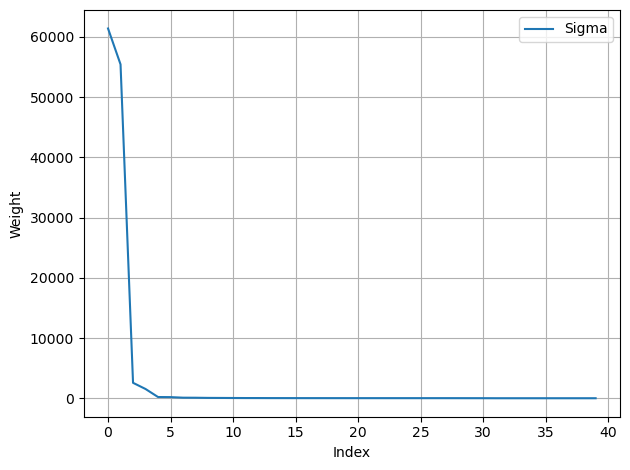

In [7]:
plt.plot(np.arange(S.shape[0]), S, label="Sigma")
plt.ylabel("Weight")
plt.legend()
plt.grid()

plt.xlabel("Index")
plt.tight_layout()
plt.show()

In [8]:
truncation_index=dominant_modes(S,thresh=0.99)+1
print(truncation_index)

8


In [9]:
truncation_index=4

In [10]:
U_tr, S_tr, Vh_tr=truncate_svd(U,S,Vh,truncation_index)

### X_N_1=[A,B]omega

In [11]:
S_tr_inv=np.diag(1/S_tr)


Ux = U_tr[:n_states, :] # 
Uu = U_tr[n_states:, :] # 

X_tilde_future = Ux.T @ X_N1


M_tilde = X_tilde_future @ Vh_tr.T @ S_tr_inv

A_tilde = M_tilde @ Ux.T @Ux # Results in 4x4
B_tilde = M_tilde @ Uu.T  # Results in 4x40

In [12]:
m1_1_m2_1_cycling_reduced=m1_1_m2_1_cycling.get_resampled_data(dt=0.01)

In [13]:
import numpy as np

def convert_to_eigenbasis(A_tilde, B_tilde, Ux):
    """
    Transforms the ROM matrices into the Diagonal Eigenbasis.
    """
    evals, V = np.linalg.eig(A_tilde)
    V_inv = np.linalg.inv(V)
    A_diag = V_inv @ A_tilde @ V
    B_diag = V_inv @ B_tilde
    C_diag = Ux @ V
    sort_idx = np.argsort(np.abs(evals))[::-1]
    A_diag_sorted = np.diag(evals[sort_idx]) 
    B_diag_sorted = B_diag[sort_idx, :]
    C_diag_sorted = C_diag[:, sort_idx]
    V_sorted = V[:, sort_idx]
    return A_diag_sorted, B_diag_sorted, C_diag_sorted, V_sorted


In [14]:
import numpy as np
import matplotlib.pyplot as plt

baseline=m1_1_m2_1_cycling_reduced

dt = dt # The sampling interval used in your preprocessing
t_end = 250 
steps = int(t_end / dt)
time_vector = np.linspace(0, t_end, steps)


# Define shapes from your matrices
n_modes = A_tilde.shape[0]
n_inputs = B_tilde.shape[1] 
n_sensors = Ux.shape[0]     
#  Initial State Preparation ---
z = np.zeros((n_modes, 1))

# Storage for results
results_T1 = np.zeros(steps)
results_T2 = np.zeros(steps)
u = np.zeros((n_inputs, 1))
u[0:20] = 0  # P1 and all 19 of its lags
u[20:40] = 0 # P2 and all 19 of its lags (set to 0)
error_T1= np.zeros(steps)
error_T2= np.zeros(steps)
real_T1= np.zeros(steps)
real_T2= np.zeros(steps)

A_d, B_d, C_d, V_transform = convert_to_eigenbasis(A_tilde, B_tilde, Ux)
z_diag = np.zeros((A_d.shape[0], 1), dtype=complex) 
z_diag_history=[]
u_history=[]

for k in range(steps):
    # Update lags for power inputs (Hankel structure maintenance)
    u[2:] = u[:-2] 
    time = k * dt
 
    u[0] = baseline.power_profile1(time) # Current P1
    u[1] = baseline.power_profile2(time) # Current P2
    
    # This is computationally efficient: z_diag_i = A_ii * z_diag_i + B_i * u
    z_diag = (A_d @ z_diag) + (B_d @ u)
    
    # T_phys = Ux @ V_transform @ z_diag = C_d @ z_diag
    T_phys = C_d @ z_diag
    
    # --- Store (Using .real to handle potential tiny imaginary parts from DMD)
    real_T1[k] = baseline.T1_profile(time)
    real_T2[k] = baseline.T2_profile(time)
    
    results_T1[k] = T_phys[0, 0].real + baseline.Ta_profile(time)
    results_T2[k] = T_phys[1, 0].real + baseline.Ta_profile(time)
    
    error_T1[k] = results_T1[k] - real_T1[k]
    error_T2[k] = results_T2[k] - real_T2[k]
    z_diag_history.append(z_diag.copy())
    u_history.append(u.copy())

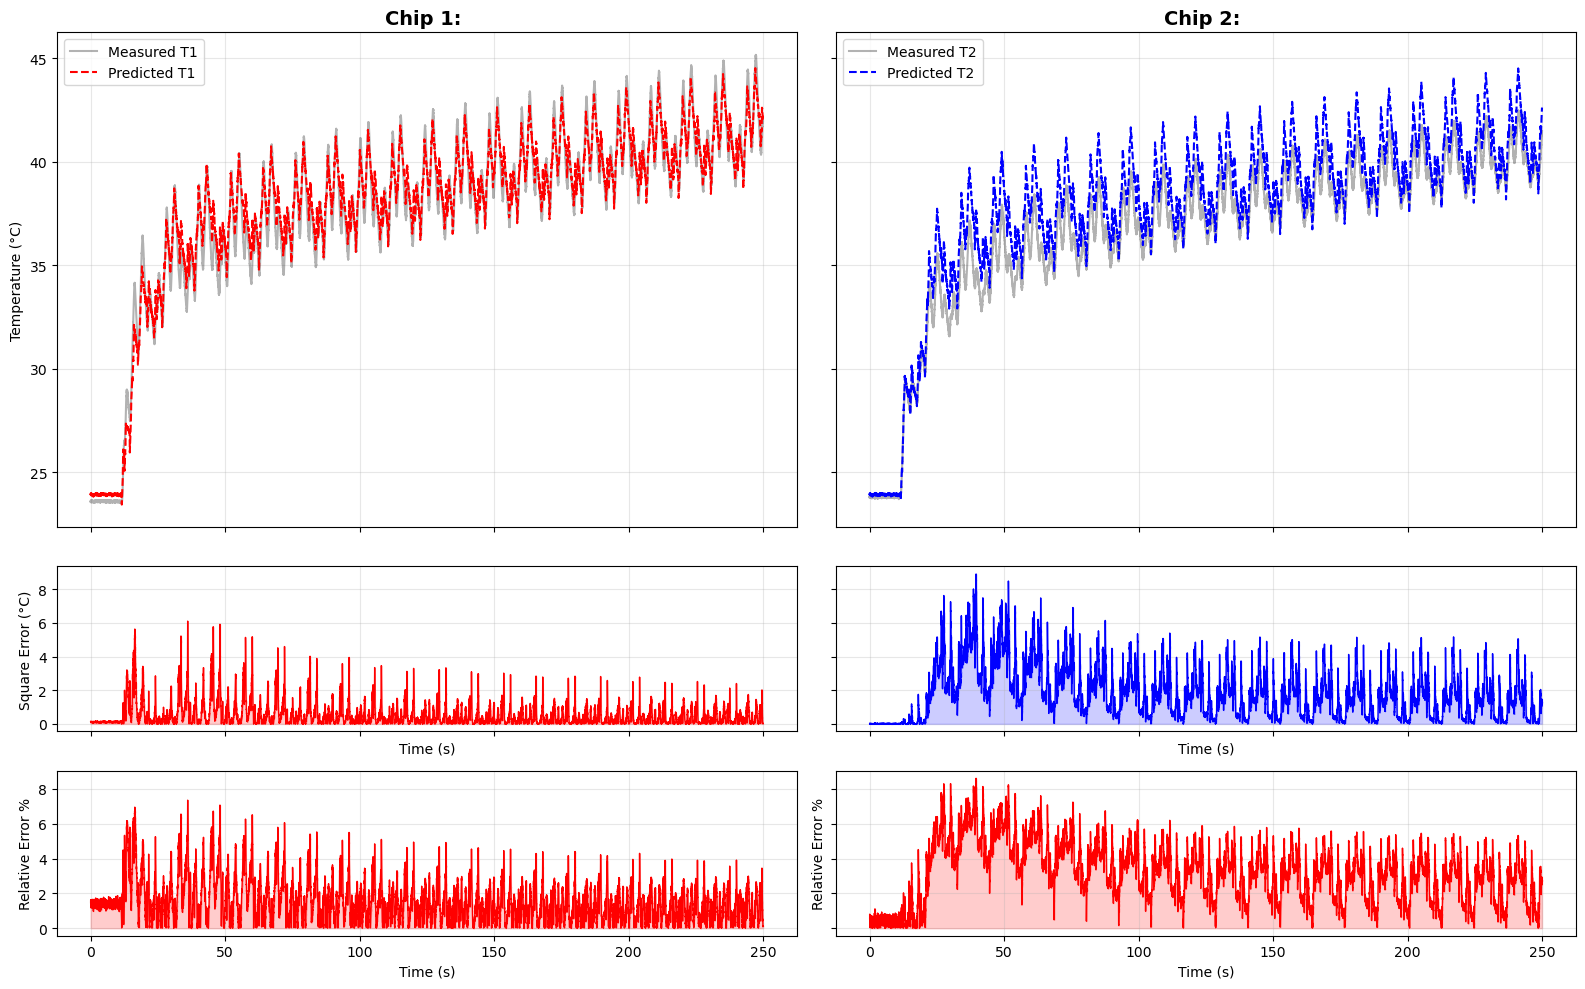

<Figure size 640x480 with 0 Axes>

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2x2 grid
# sharex=True ensures zooming in on time zooms both chips
# sharey='row' helps compare the magnitude of the errors between chips
fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True, sharey='row',
                         gridspec_kw={'height_ratios': [3, 1,1]})

# --- CHIP 1: ---
# Temperature Plot
axes[0, 0].plot(time_vector, real_T1, 'k-', alpha=0.3, label='Measured T1')
axes[0, 0].plot(time_vector, results_T1, 'r--', linewidth=1.5, label='Predicted T1')
axes[0, 0].set_title("Chip 1: ", fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel("Temperature (°C)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Error Plot squared
axes[1, 0].fill_between(time_vector, error_T1**2, color='red', alpha=0.2)
axes[1, 0].plot(time_vector, error_T1**2, 'r-', linewidth=1)
axes[1, 0].set_ylabel("Square Error (°C)")
axes[1, 0].set_xlabel("Time (s)")
axes[1, 0].grid(True, alpha=0.3)

# Error Plot Relative
axes[2, 0].fill_between(time_vector, 100*np.abs(error_T1)/real_T1, color='red', alpha=0.2)
axes[2, 0].plot(time_vector, 100*np.abs(error_T1)/real_T1, 'r-', linewidth=1)
axes[2, 0].set_ylabel("Relative Error %")
axes[2, 0].set_xlabel("Time (s)")
axes[2, 0].grid(True, alpha=0.3)


# --- CHIP 2: ---
# Temperature Plot
axes[0, 1].plot(time_vector, real_T2, 'k-', alpha=0.3, label='Measured T2')
axes[0, 1].plot(time_vector, results_T2, 'b--', linewidth=1.5, label='Predicted T2')
axes[0, 1].set_title("Chip 2: ", fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Error Plot
axes[1, 1].fill_between(time_vector, error_T2**2, color='blue', alpha=0.2)
axes[1, 1].plot(time_vector, error_T2**2, 'b-', linewidth=1)
axes[1, 1].set_xlabel("Time (s)")
axes[1, 1].grid(True, alpha=0.3)

# Error Plot Relative
axes[2, 1].fill_between(time_vector, 100*np.abs(error_T2)/real_T2, color='red', alpha=0.2)
axes[2, 1].plot(time_vector, 100*np.abs(error_T2)/real_T2, 'r-', linewidth=1)
axes[2, 1].set_ylabel("Relative Error %")
axes[2, 1].set_xlabel("Time (s)")
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.savefig("offline_DMD_vs_real.svg", format="svg")




In [16]:
print(f"Mean Square Error T1: {np.mean(error_T1**2):.3f}°C^2")
print(f"Mean Square Error T2: {np.mean(error_T2**2):.3f}°C^2")
print(f"Mean Relative Error T1: {np.mean(100*np.abs(error_T1)/real_T1):.3f}%")
print(f"Mean Relative Error T2: {np.mean(100*np.abs(error_T2)/real_T2):.3f}%")
print(f"Max Square Error T1: {np.max(error_T1**2):.3f}°C^2")
print(f"Max Square Error T1: {np.max(error_T2**2):.3f}°C^2")

Mean Square Error T1: 0.543°C^2
Mean Square Error T2: 1.797°C^2
Mean Relative Error T1: 1.606%
Mean Relative Error T2: 3.191%
Max Square Error T1: 6.104°C^2
Max Square Error T1: 8.904°C^2


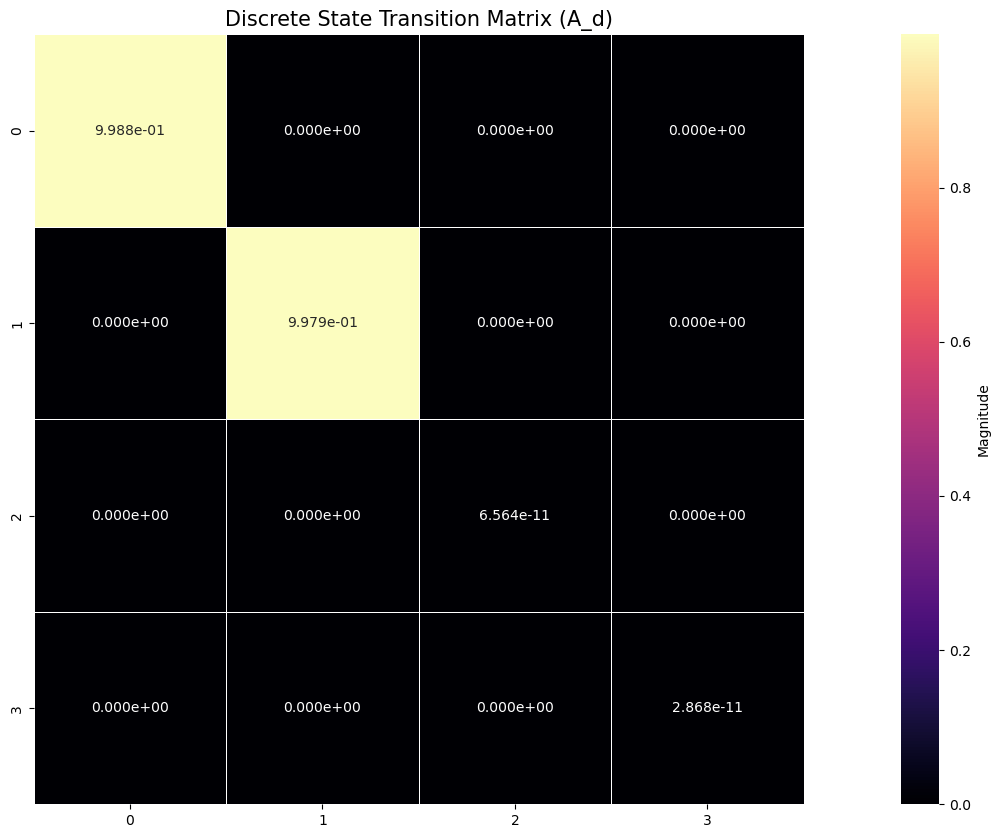

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_thermal_matrix(matrix, title="Matrix Visualization"):
    plt.figure(figsize=(25, 10))
    
    # 'fmt=".1e"' ensures scientific notation
    # 'annot=True' writes the values in the cells
    # 'cmap="magma"' is perceptually uniform and good for heat transfer
    # 'robust=True' uses quantiles for the color scale, preventing outliers from washing out colors
    
    ax = sns.heatmap(
        matrix, 
        annot=True, 
        fmt=".3e", 
        cmap="magma", 
        linewidths=0.5,
        square=True,
        cbar_kws={'label': 'Magnitude'},
        annot_kws={"size": 10}
    )
    
    plt.title(title, fontsize=15)
    plt.show()


plot_thermal_matrix(A_d, title="Discrete State Transition Matrix (A_d)")

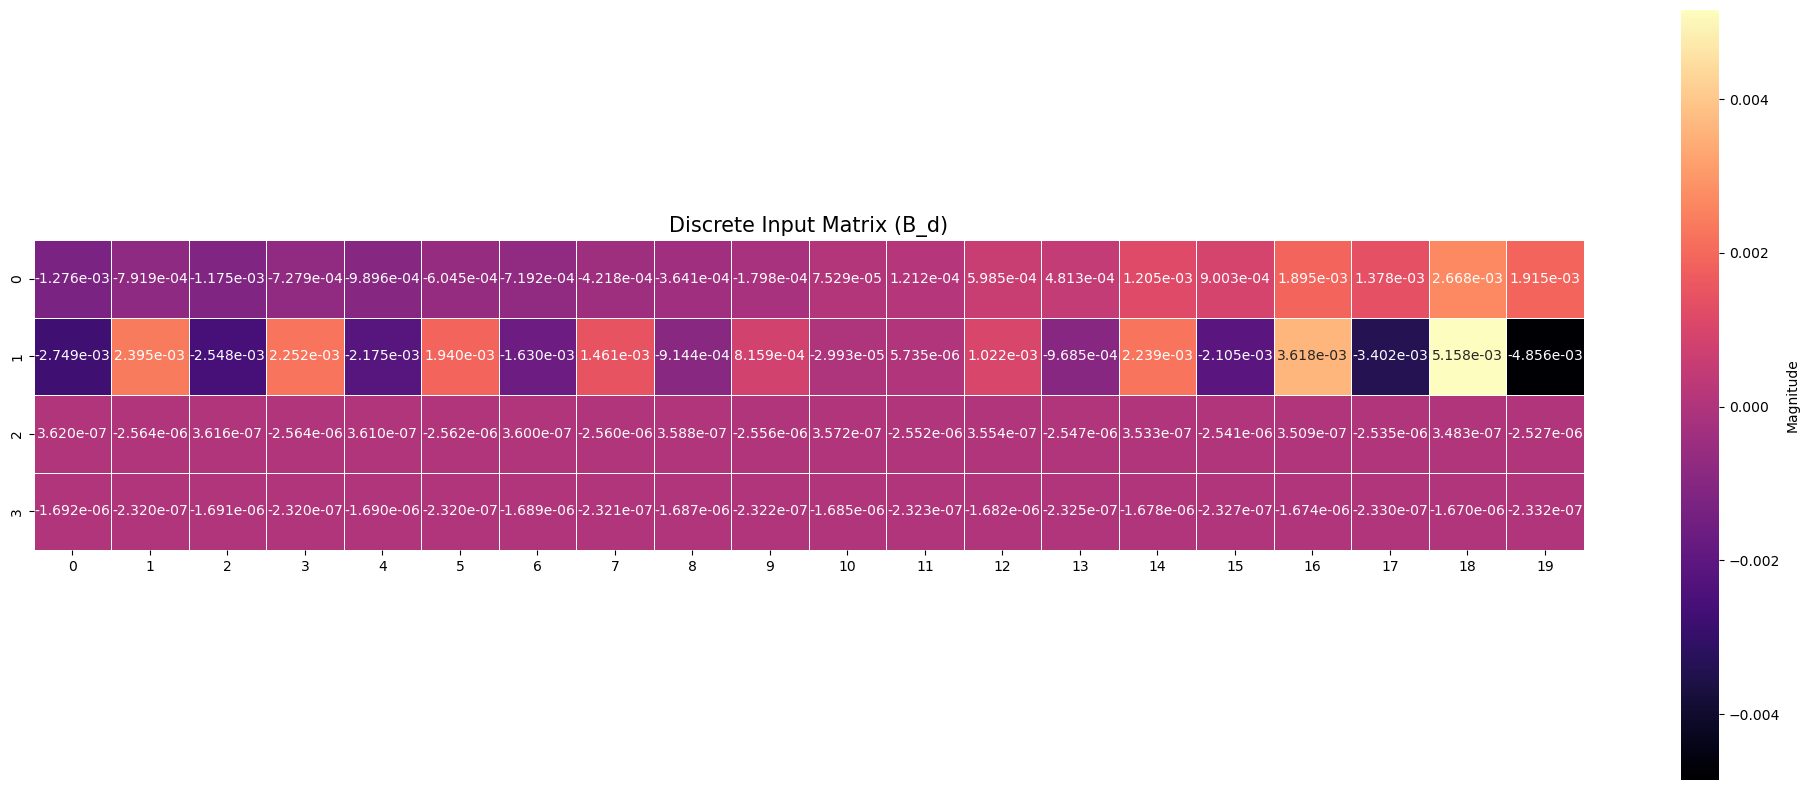

In [18]:
plot_thermal_matrix(B_d, title="Discrete Input Matrix (B_d)")

In [19]:

class DMDSimulator:
    def __init__(self, A_d, B_d, C_d, dt):
        """
        A_d: Diagonalized State Transition (n_modes x n_modes)
        B_d: Input Matrix (n_modes x n_inputs)
        C_d: Observation Matrix (n_sensors x n_modes)
        dt: Sampling time
        """
        self.A_d = A_d
        self.B_d = B_d
        self.C_d = C_d
        self.dt = dt
        self.A_diag_vec = np.diag(A_d).reshape(-1, 1)
        
        self.n_modes = A_d.shape[0]
        self.n_inputs = B_d.shape[1]
        self.n_sensors = C_d.shape[0]
        
        # Internal state and buffer initialization
        self.z_diag = np.zeros((self.n_modes, 1), dtype=complex)
        self.u_buffer = np.zeros((self.n_inputs, 1)) 
        
    def reset(self):
        """Resets the internal state and lag buffer to zero."""
        self.z_diag = np.zeros((self.n_modes, 1), dtype=complex)
        self.u_buffer = np.zeros((self.n_inputs, 1))

    def predict_next_step(self, p1, p2):
        self.u_buffer[2:] = self.u_buffer[:-2]
        self.u_buffer[0] = p1
        self.u_buffer[1] = p2
        
        # State Update: Element-wise A * z + dot(B, u)
        self.z_diag = (self.A_diag_vec * self.z_diag) + (self.B_d @ self.u_buffer)
        T_phys=(self.C_d @ self.z_diag).real.flatten()
        T_phys = np.maximum(0, T_phys)
        return T_phys

    def simulate(self, t_end, p1_func, p2_func, Ta_func=None):
        """Simulates a profile by looping over predict_next_step."""
        self.reset()
        steps = int(t_end / self.dt)
        time_vector = np.linspace(0, t_end, steps)
        results = np.zeros((self.n_sensors, steps))
        
        for k in range(steps):
            t = k * self.dt
            T_phys = self.predict_next_step(p1_func(t), p2_func(t))
            offset = Ta_func(t) if Ta_func else 0
            results[:, k] = T_phys + offset
        return time_vector, results

    def simulate_step(self, t_end, p_magnitude=1, active_chip=0, sensor_idx=0):
        """Generates a clean step response for characterization."""
        p1_val = lambda t: p_magnitude if active_chip == 0 else 0
        p2_val = lambda t: p_magnitude if active_chip == 1 else 0
        
        t_vec, T_all = self.simulate(t_end, p1_val, p2_val, Ta_func=None)
        return t_vec, T_all[sensor_idx, :]

## Online DMD

In [20]:
import numpy as np

class OnlineDMDc_Decoupled:
    def __init__(self, n_state, n_input, rho=0.99, w_init=1e4):
        self.r = n_state
        self.l = n_input
        self.rho = rho
        self.dim = n_state + n_input
        
        # Initialize G and P
        self.G = np.zeros((self.r, self.dim))
        self.P = w_init * np.eye(self.dim)

        self.mask = np.ones((self.r, self.dim))

    def initialize_from_decoupled(self, A_diag, B_diag, X_diag_hist, U_hist):
        """
        1. Sets G = [A_diag, B_diag]
        2. Creates the Mask to enforce diagonal structure.
        3. Initializes P.
        """
        # Set the model
        self.G = np.hstack((A_diag, B_diag))
        
        #  Create the Mask (first the part of the mask for A (it is diagonal))
      
        self.mask[:, :self.r] = 0.0 
        
        np.fill_diagonal(self.mask[:, :self.r], 1.0)
        
        # Part of the mask for B (consider everything ) set to 1
 
        self.mask[:, self.r:] = 1.0
        
        # exp freezing the fast eig

        eigenvalues = np.diag(A_diag)
        fast_indices = np.where(np.abs(eigenvalues) < 0.001)[0]
        
        if len(fast_indices) > 0:
            print(f"freezing{len(fast_indices)} fast modes.")
            self.mask[fast_indices, :] = 0.0
            
        # Initialize P 
        Omega = np.vstack((X_diag_hist, U_hist))
        epsilon = 1e-6 * np.eye(self.dim)
        self.P = np.linalg.inv((Omega @ Omega.T) + epsilon)

    def update(self, z_k, u_k, z_next):
        #  RLS
        x = np.vstack((z_k, u_k))
        Px = self.P @ x
        gamma = 1.0 / (self.rho + (x.T @ Px))
        g = Px * gamma
        
        z_pred = self.G @ x
        error = z_next - z_pred
        
        #  Update 
        delta_G = error @ g.T
        
  
        # forces diag system and keeps the fast modes static
        delta_G = delta_G * self.mask
        
        # 4. Update Matrices
        self.G = self.G + delta_G
        
        # Update P 
        self.P = (1.0 / self.rho) * (self.P - (g @ Px.T)) 
        self.P += 1e-5 * np.eye(self.dim) 

    def predict(self, z_k, u_k):
        x = np.vstack((z_k, u_k))
        z_next_pred = self.G @ x
        return z_next_pred

    @property
    def A(self):
        return self.G[:, :self.r]

    @property
    def B(self):
        return self.G[:, self.r:]

In [21]:

import numpy as np
from scipy.optimize import linear_sum_assignment

def track_modes_by_distance(current_eigs, previous_eigs):
    """
    Reorders current_eigs to match the order of previous_eigs
    based on minimum distance in the complex plane.
    """

    dist_matrix = np.abs(current_eigs[:, None] - previous_eigs[None, :])

    row_ind, col_ind = linear_sum_assignment(dist_matrix)
    

    sorted_eigs = np.zeros_like(current_eigs)
    sorted_eigs[col_ind] = current_eigs[row_ind]
    
    return sorted_eigs

In [22]:
n_modes = 4
X_N_reduced = Ux.T @ X_N #XN prjection into z modes
V_inv = np.linalg.inv(V_transform)

# (n_modes, n_snapshots)
X_diag_hist = V_inv @ X_N_reduced #z modes projection into z diag
n_inputs=B_tilde.shape[1]
learner = OnlineDMDc_Decoupled(n_state=n_modes, n_input=n_inputs, rho=0.999)
learner.initialize_from_decoupled(A_d*0.8, B_d, X_diag_hist, U_N)#test with 1.5* gain to see if it can learn to reduce it back
initial_A = learner.A
eigs_prev = np.linalg.eigvals(initial_A)
eigs_prev = eigs_prev[np.argsort(np.abs(eigs_prev))[::-1]] # Sort once
eigs_history = [eigs_prev]
A_history = [initial_A]
B_history = [learner.B]
for k in range(steps-1):
    t=k*dt
    z_current = z_diag_history[k].reshape(-1, 1)   # 4x1
    u_current = u_history[k].reshape(-1, 1)   # 20x1
    z_next    = z_diag_history[k+1].reshape(-1, 1)
    learner.update(z_current, u_current, z_next)
    current_A = learner.A
    eigs_raw = np.linalg.eigvals(learner.A)
    eigs_tracked = track_modes_by_distance(eigs_raw, eigs_prev)
    eigs_history.append(eigs_tracked)
    eigs_prev = eigs_tracked
    A_history.append(current_A)
    B_history.append(learner.B)

freezing2 fast modes.


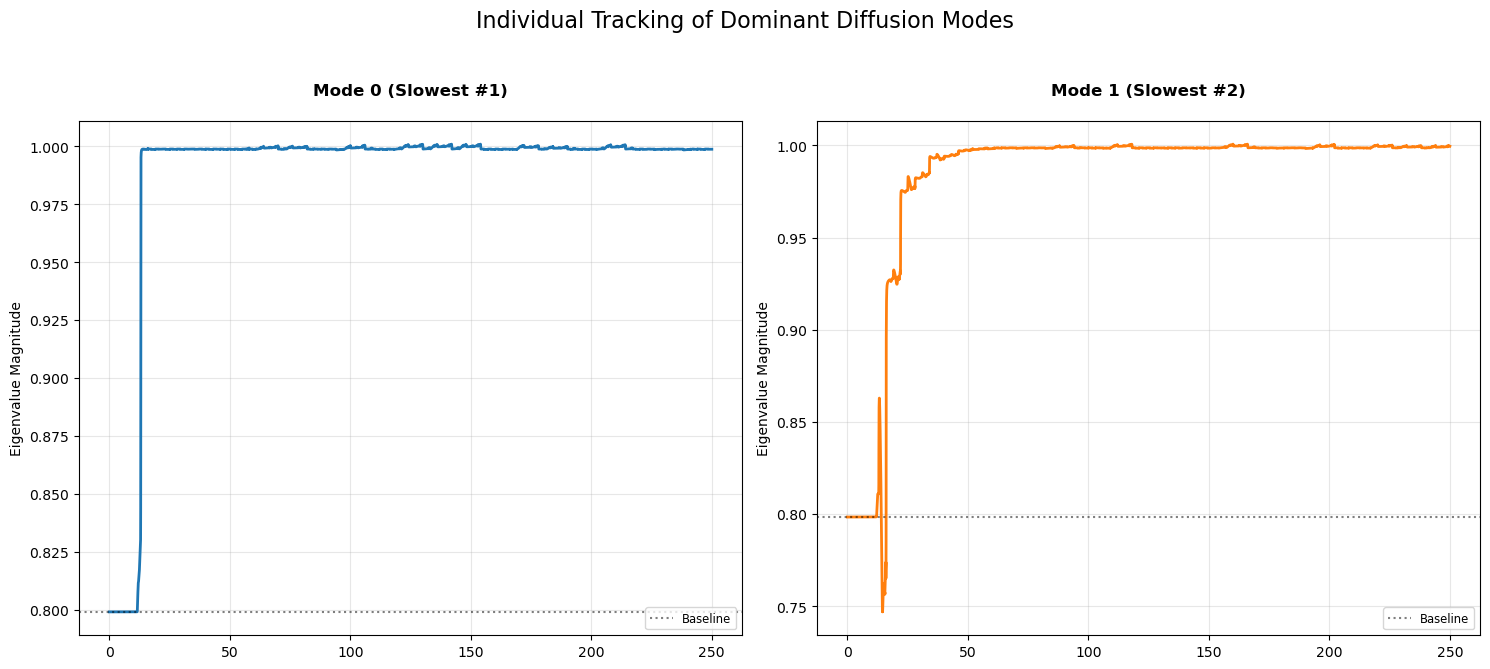

<Figure size 640x480 with 0 Axes>

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Convert history to a numpy array (Time x Modes)
eigs_arr = np.array(eigs_history)
n_steps, n_modes = eigs_arr.shape
dt = time_vector[1] - time_vector[0]

# 2. Identify the 4 most dominant (slowest) eigenvalues
# We sort based on the mean magnitude over the entire run
mean_mags = np.mean(np.abs(eigs_arr), axis=0)
dominant_indices = np.argsort(mean_mags)[-4:][::-1] # Get top 4 indices

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True)
axes = axes.flatten()
i=0
for i, mode_idx in enumerate(dominant_indices):
    # Extract magnitude for this specific eigenvalue
    mag_series = np.abs(eigs_arr[:, mode_idx])
    
    # Calculate the physical time constant (tau) for the final state
    # tau = -dt / ln(|lambda|)
    final_tau = -dt / np.log(mag_series[-1])
    
    # Plotting
    axes[i].plot(time_vector[:n_steps], mag_series, color=f'C{i}', linewidth=2)
    
    # Add a horizontal line for the initial baseline (to see the drift)
    axes[i].axhline(mag_series[0], color='black', linestyle=':', alpha=0.5, label='Baseline')
    
    # Labeling with physical context
    axes[i].set_title(f"Mode {mode_idx} (Slowest #{i+1})\n"
                      , 
                      fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Eigenvalue Magnitude")
    axes[i].grid(True, alpha=0.3)
    if i >= 2: axes[i].set_xlabel("Time (s)")
    axes[i].legend(loc='lower right', fontsize='small')
    if i==1:
        break
    i+=1

plt.suptitle("Individual Tracking of Dominant Diffusion Modes", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.savefig("online_DMD_convergence.svg", format="svg")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import copy

# --- 1. Initialization ---
n_modes = 4
X_N_reduced = Ux.T @ X_N 
V_inv = np.linalg.inv(V_transform)
X_diag_hist = V_inv @ X_N_reduced 
n_inputs = B_tilde.shape[1]

# Initialize Online Learner 
learner = OnlineDMDc_Decoupled(n_state=n_modes, n_input=n_inputs, rho=0.999)
learner.initialize_from_decoupled(A_d*0.8, B_d * 1.5, X_diag_hist, U_N)#test with 1.5* gain to see if it can learn to reduce it back

# Sandbox Simulator for Characterization
live_twin = DMDSimulator(learner.A.copy(), learner.B.copy(), C_d, dt)


# --- DUAL STATES ---
z_obs = np.zeros((n_modes, 1), dtype=complex)  
z_shadow = np.zeros((n_modes, 1), dtype=complex) 

T_shadow_history = []
T_obs_history = []
cauer_history = []

alpha = 0.1 
characterization_interval = int(50 / dt) 

for k in range(steps - 1):
    t = k * dt
    
    # 1. Reality Check
    z_measured = z_diag_history[k].reshape(-1, 1)   
    u_current = u_history[k].reshape(-1, 1)        
    z_next_measured = z_diag_history[k+1].reshape(-1, 1) 
    
    p1 = baseline.power_profile1(t)
    p2 = baseline.power_profile2(t)
    Ta = baseline.Ta_profile(t)
    
    #Update the Learner 
    learner.update(z_measured, u_current, z_next_measured)
    
    # Update Characterizer Sandbox
    live_twin.A_d = learner.A
    live_twin.B_d = learner.B
    
    # ADVANCE SHADOW TWIN 
    z_shadow = (learner.A @ z_shadow) + (learner.B @ u_current)
    T_shadow = (C_d @ z_shadow).real.flatten()
    T_shadow = np.maximum(0, T_shadow) # Physicality clamp
    T_shadow_history.append((t, T_shadow + Ta))
    
    # ADVANCE OBSERVER  
    z_obs_pred = (learner.A @ z_obs) + (learner.B @ u_current)
    z_obs = z_obs_pred + alpha * (z_next_measured - z_obs_pred)
    T_obs = (C_d @ z_obs).real.flatten()
    T_obs = np.maximum(0, T_obs)
    T_obs_history.append((t, T_obs + Ta))
    
print("Simulation Complete. Plotting Results...")



freezing2 fast modes.
Simulation Complete. Plotting Results...


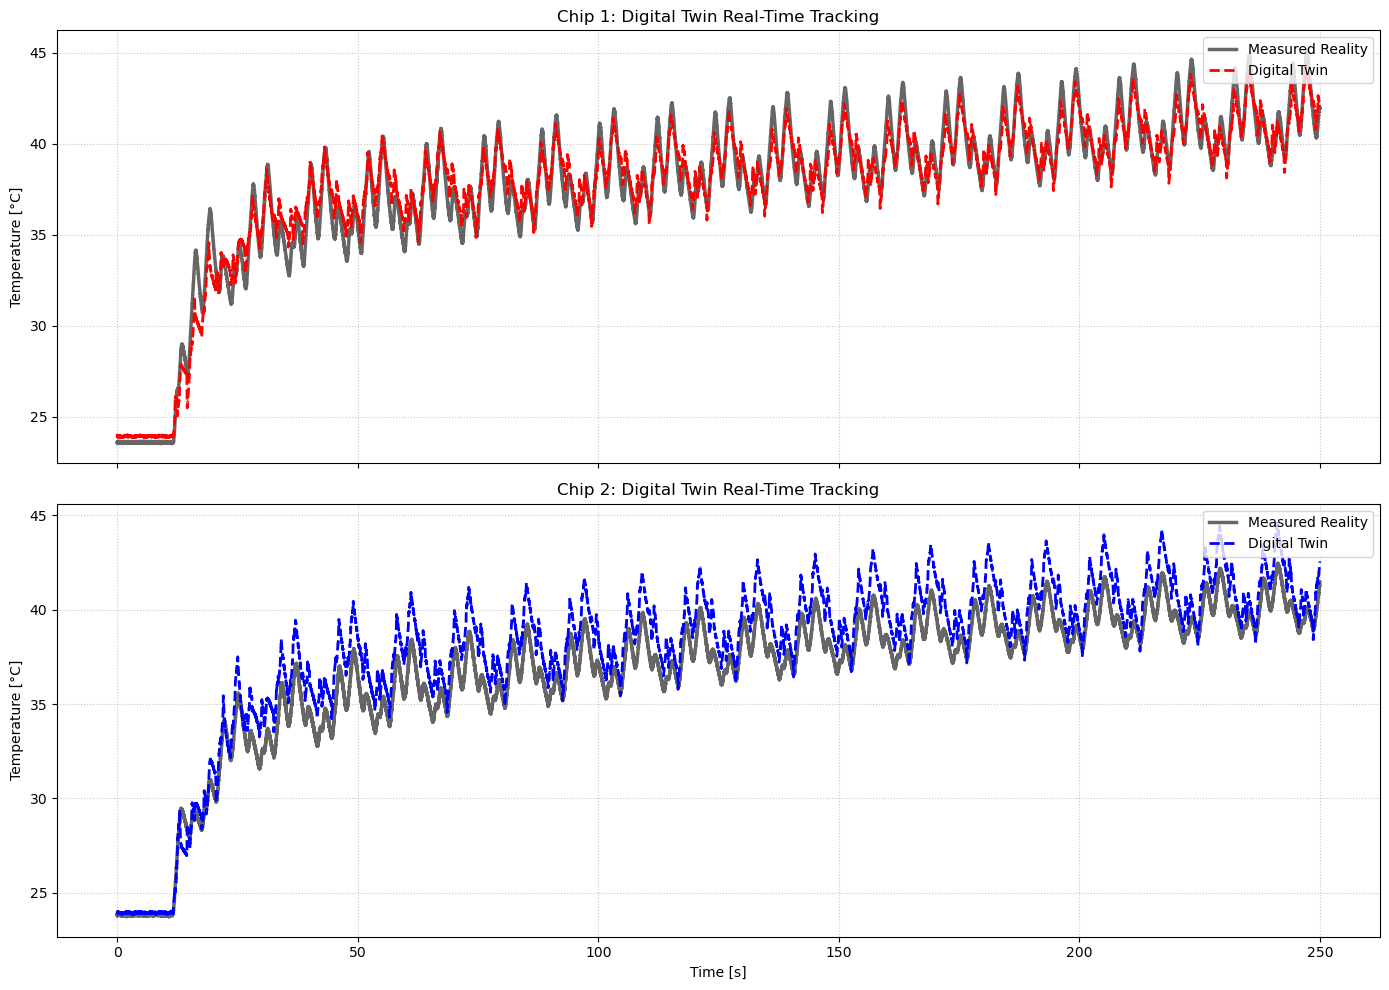

<Figure size 640x480 with 0 Axes>

In [25]:
# --- 3. Plotting Function ---
def plot_learning_convergence(T_shadow_hist, T_obs_hist, baseline, steps, dt):
    times = np.array([entry[0] for entry in T_shadow_hist])
    
    # Shadow (Open-Loop) predictions
    pred_shadow_T1 = np.array([entry[1][0] for entry in T_shadow_hist])
    pred_shadow_T2 = np.array([entry[1][1] for entry in T_shadow_hist])
    
    # Observer (Corrected) predictions
    pred_obs_T1 = np.array([entry[1][0] for entry in T_obs_hist])
    pred_obs_T2 = np.array([entry[1][1] for entry in T_obs_hist])
    
    # Measured Reality
    real_T1 = np.array([baseline.T1_profile(t) for t in times])
    real_T2 = np.array([baseline.T2_profile(t) for t in times])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # --- Chip 1 ---
    ax1.plot(times, real_T1, 'k-', lw=2.5, alpha=0.6, label='Measured Reality')
    ax1.plot(times, pred_shadow_T1, 'r--', lw=2, label='Digital Twin')
    #ax1.plot(times, pred_obs_T1, 'g:', lw=2, alpha=0.8, label='Observer Twin (Corrected)')
    ax1.set_ylabel('Temperature [°C]')
    ax1.set_title('Chip 1: Digital Twin Real-Time Tracking')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    # --- Chip 2 ---
    ax2.plot(times, real_T2, 'k-', lw=2.5, alpha=0.6, label='Measured Reality')
    ax2.plot(times, pred_shadow_T2, 'b--', lw=2, label='Digital Twin')
    #ax2.plot(times, pred_obs_T2, 'c:', lw=2, alpha=0.8, label='Observer Twin (Corrected)')
    ax2.set_ylabel('Temperature [°C]')
    ax2.set_xlabel('Time [s]')
    ax2.set_title('Chip 2: Digital Twin Real-Time Tracking')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    plt.savefig("Digital_twin_DMD.svg", format="svg")


# Execute the plot
plot_learning_convergence(T_shadow_history, T_obs_history, baseline, steps, dt)

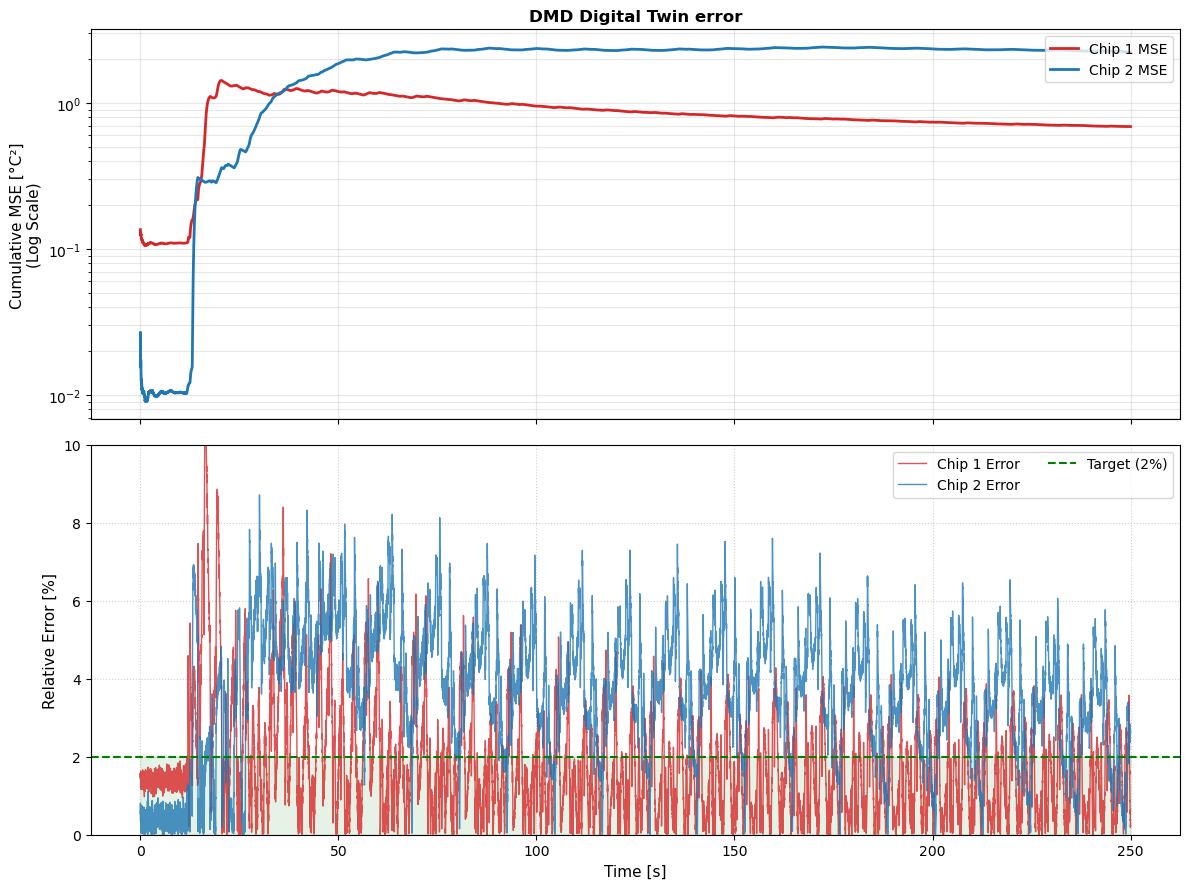

<Figure size 640x480 with 0 Axes>

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def plot_advanced_error_metrics(T_shadow_hist, baseline):
    times = np.array([entry[0] for entry in T_shadow_hist])
    
    # Extract data
    pred_T1 = np.array([entry[1][0] for entry in T_shadow_hist])
    pred_T2 = np.array([entry[1][1] for entry in T_shadow_hist])
    real_T1 = np.array([baseline.T1_profile(t) for t in times])
    real_T2 = np.array([baseline.T2_profile(t) for t in times])

    # Calculations
    err1, err2 = pred_T1 - real_T1, pred_T2 - real_T2
    
    # Running MSE (Cumulative)
    mse1 = np.cumsum(err1**2) / (np.arange(len(err1)) + 1)
    mse2 = np.cumsum(err2**2) / (np.arange(len(err2)) + 1)
    
    # Relative Error (%)
    rel_err1 = (np.abs(err1) / (np.abs(real_T1) + 1e-6)) * 100
    rel_err2 = (np.abs(err2) / (np.abs(real_T2) + 1e-6)) * 100

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

    # --- Subplot 1: Convergence (Log Scale) ---
    ax1.semilogy(times, mse1, color='#d62728', lw=2, label='Chip 1 MSE')
    ax1.semilogy(times, mse2, color='#1f77b4', lw=2, label='Chip 2 MSE')
    ax1.set_ylabel('Cumulative MSE [°C²]\n(Log Scale)', fontsize=11)
    ax1.set_title('DMD Digital Twin error', fontweight='bold')
    ax1.grid(True, which="both", ls="-", alpha=0.3)
    ax1.legend(loc='upper right', frameon=True)

    # --- Subplot 2: Relative Error with Tolerance Zone ---
    ax2.plot(times, rel_err1, color='#d62728', alpha=0.8, lw=1, label='Chip 1 Error')
    ax2.plot(times, rel_err2, color='#1f77b4', alpha=0.8, lw=1, label='Chip 2 Error')
    
    # Add a horizontal target zone (e.g., 2% error is standard for DTs)
    ax2.axhline(y=2, color='green', linestyle='--', lw=1.5, label='Target (2%)')
    ax2.fill_between(times, 0, 2, color='green', alpha=0.1) # Shaded "Pass" region
    
    ax2.set_ylabel('Relative Error [%]', fontsize=11)
    ax2.set_xlabel('Time [s]', fontsize=11)
    ax2.set_ylim(0, 10) # Clip peaks for legibility; 10% is already "failing" for a DT
    ax2.grid(True, ls=":", alpha=0.6)
    ax2.legend(loc='upper right', ncol=2)

    plt.tight_layout()
    plt.show()
    plt.savefig("DMD_error_metrics.svg", format="svg")

plot_advanced_error_metrics(T_shadow_history, baseline)